In [17]:

import matplotlib
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

sns.set(style="whitegrid", context="talk", palette=sns.color_palette("bright"), color_codes=False)
matplotlib.rc('font', family='sans-serif') 
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['mathtext.cal'] = 'stix:italic'  # changes only the mathcal subfamily


markers = ['s', 'o', '^', '*', 'v', 'X', '+', 'P', '.', 6, 7]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.datasets import fetch_covtype, fetch_openml

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

DATA = "covtype"   # or "w8a"
ITERS = 1000
SEED = 0
BATCH_SIZE = None   # None or >= n => full-batch. e.g., 2048 for mini-batch
BATCH_SIZE = 581012//10   # None or >= n => full-batch. e.g., 2048 for mini-batch
SHUFFLE = True
DROP_LAST = True

if DATA.lower() == "covtype":
    X, y = fetch_covtype(return_X_y=True)
    X = X.astype(np.float64)
    y = (y == 1).astype(np.float64)
elif DATA.lower() == "w8a":
    X, y = fetch_openml("w8a", version=1, as_frame=False, return_X_y=True)
    if sp.issparse(X): X = X.toarray()
    X = X.astype(np.float64)
    y = (y.astype(np.int32) == 1).astype(np.float64)
else:
    raise ValueError("Unknown DATA")

n = X.shape[0]
mu, sd = X.mean(0), X.std(0) + 1e-8
X = (X - mu) / sd
X = np.hstack([X, np.ones((X.shape[0], 1), np.float64)])  # bias
Xj = jnp.array(X, dtype=jnp.float64)
yj = jnp.array(y, dtype=jnp.float64)
d  = Xj.shape[1]

def iter_minibatches(X, y, batch_size, key, shuffle=True, drop_last=True):
    n = X.shape[0]
    if (batch_size is None) or (batch_size >= n):
        yield X, y
        return
    idx = jnp.arange(n)
    if shuffle:
        idx = jax.random.permutation(key, idx)
    m = (n // batch_size) * batch_size if drop_last else n
    for i in range(0, m, batch_size):
        sel = idx[i:i+batch_size]
        yield X[sel], y[sel]

def loss_batch(w, Xb, yb):
    z = Xb @ w
    # NLL:  -y log σ(z) - (1-y) log σ(-z)
    return jnp.mean(- yb * jax.nn.log_sigmoid(z) - (1.0 - yb) * jax.nn.log_sigmoid(-z))

grad = jax.jit(lambda w, Xb, yb: jax.grad(loss_batch)(w, Xb, yb))
hvp  = jax.jit(lambda w, v, Xb, yb: jax.jvp(lambda ww: jax.grad(loss_batch)(ww, Xb, yb), (w,), (v,))[1])
loss_jit = jax.jit(loss_batch)

def lam_max_cov():
    S = (Xj.T @ Xj) / Xj.shape[0]
    v = jax.random.normal(jax.random.PRNGKey(SEED), (d,))
    for _ in range(50):
        v = S @ v
        v = v / (jnp.linalg.norm(v) + 1e-12)
    return float(v @ (S @ v))


In [19]:

def estimate_step_gd():
    L = 0.25 * lam_max_cov()
    return 1.0 / (L + 1e-12)

class SGD:
    def __init__(self, eta): 
        self.eta = float(eta)
        
    def step(self, w, Xb, yb):
        g = grad(w, Xb, yb)
        return (w - self.eta * g).astype(w.dtype)

class CaCuSGD:
    def __init__(self, H_hat=1.0, L_hat=1e+3):
        self.H_hat = float(H_hat)
        self.eta = float(1/L_hat)

    def step(self, w, Xb, yb):
        g  = grad(w, Xb, yb).block_until_ready()
        gn = float(jnp.linalg.norm(g))
        if not np.isfinite(gn) or gn == 0.0:
            return w

        Hg = hvp(w, g, Xb, yb).block_until_ready()
        p  = float(jnp.vdot(g, Hg))
        fx = float(loss_jit(w, Xb, yb).block_until_ready())

        Hb = (p**2) / (gn**5) * 4.0

        if Hb < self.H_hat:
            # print(f"{Hb=}")
            s = - g / jnp.sqrt(self.H_hat * gn)
        else:
            s = -self.eta * g

        return (w + s).astype(w.dtype)



def run(opt, iters, batch_size=None, seed=SEED, log_full_loss=True):
    key = jax.random.PRNGKey(seed)
    w = jnp.zeros((d,), dtype=jnp.float64)
    _ = loss_jit(w, Xj, yj).block_until_ready()

    hist = []
    t0 = time.time()
    steps = 0
    while steps < iters:
        key, sub = jax.random.split(key)
        for Xb, yb in iter_minibatches(Xj, yj, batch_size, sub, shuffle=SHUFFLE, drop_last=DROP_LAST):
            if log_full_loss:
                hist.append(float(loss_jit(w, Xj, yj).block_until_ready()))
            else:
                hist.append(float(loss_jit(w, Xb, yb).block_until_ready()))
            w = opt.step(w, Xb, yb)
            steps += 1
            if steps >= iters: break
    t1 = time.time()
    return w, hist, (t1 - t0)



f_opt = 0.46571386293525935

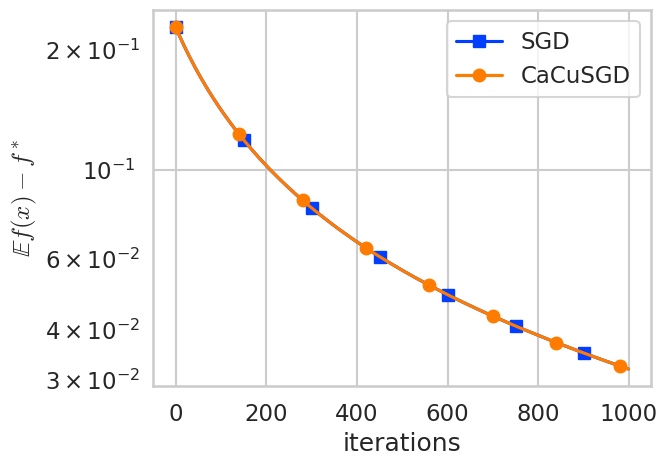

In [20]:
eta = 0.01
w_gd, hist_gd, t_gd = run(SGD(eta), ITERS, batch_size=BATCH_SIZE)

H_hat=1e-1
opt_cb = CaCuSGD(H_hat=H_hat, L_hat=1/eta)
w_cb, hist_cb, t_cb = run(opt_cb, ITERS, batch_size=BATCH_SIZE)


plt.figure(figsize=(7,5))
plt.semilogy(np.arange(len(hist_gd)), np.array(hist_gd) - f_opt, label="SGD", marker=markers[0], markevery=150)
plt.semilogy(np.arange(len(hist_cb)), np.array(hist_cb) - f_opt, label="CaCuSGD", marker=markers[1], markevery=140)
plt.xlabel("iterations")
plt.ylabel(r'$\mathbb{E} f(x)-f^*$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f'cacusgd_{H_hat,eta}.pdf', bbox_inches='tight')
plt.show()

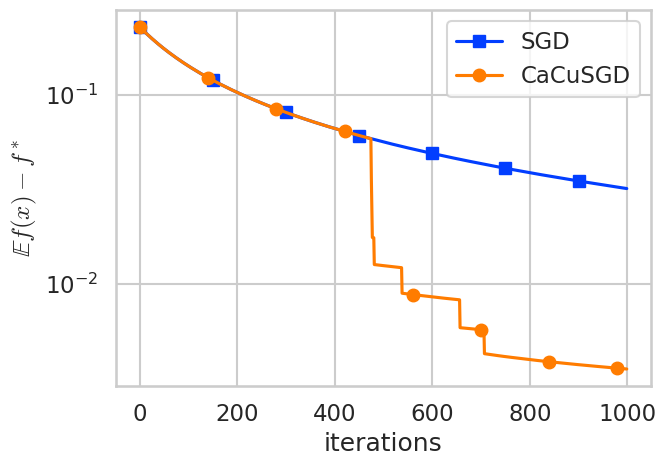

In [21]:
H_hat=1e0
opt_cb = CaCuSGD(H_hat=H_hat, L_hat=1/eta)
w_cb, hist_cb, t_cb = run(opt_cb, ITERS, batch_size=BATCH_SIZE)


plt.figure(figsize=(7,5))
plt.semilogy(np.arange(len(hist_gd)), np.array(hist_gd) - f_opt, label="SGD", marker=markers[0], markevery=150)
plt.semilogy(np.arange(len(hist_cb)), np.array(hist_cb) - f_opt, label="CaCuSGD", marker=markers[1], markevery=140)
plt.xlabel("iterations")
plt.ylabel(r'$\mathbb{E} f(x)-f^*$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f'cacusgd_{H_hat,eta}.pdf', bbox_inches='tight')
plt.show()

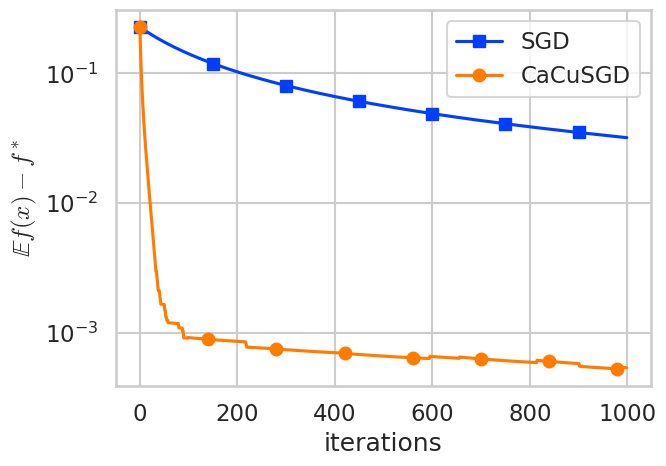

In [22]:
H_hat=1e1
opt_cb = CaCuSGD(H_hat=H_hat, L_hat=1/eta)
w_cb, hist_cb, t_cb = run(opt_cb, ITERS, batch_size=BATCH_SIZE)


plt.figure(figsize=(7,5))
plt.semilogy(np.arange(len(hist_gd)), np.array(hist_gd) - f_opt, label="SGD", marker=markers[0], markevery=150)
plt.semilogy(np.arange(len(hist_cb)), np.array(hist_cb) - f_opt, label="CaCuSGD", marker=markers[1], markevery=140)
plt.xlabel("iterations")
plt.ylabel(r'$\mathbb{E} f(x)-f^*$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f'cacusgd_{H_hat,eta}.pdf', bbox_inches='tight')
plt.show()

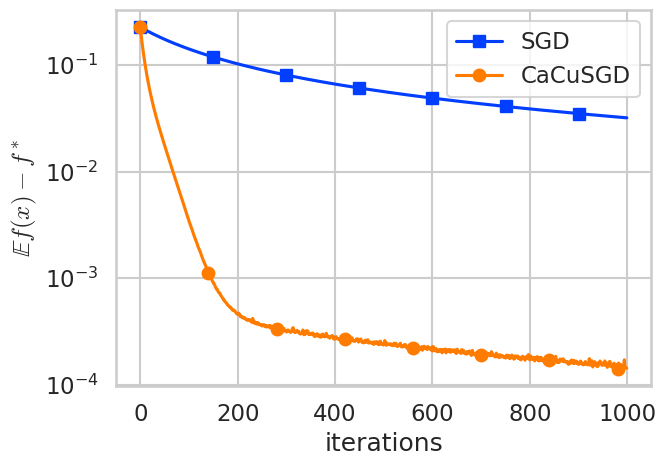

In [23]:
H_hat=1e2
opt_cb = CaCuSGD(H_hat=H_hat, L_hat=1/eta)
w_cb, hist_cb, t_cb = run(opt_cb, ITERS, batch_size=BATCH_SIZE)


plt.figure(figsize=(7,5))
plt.semilogy(np.arange(len(hist_gd)), np.array(hist_gd) - f_opt, label="SGD", marker=markers[0], markevery=150)
plt.semilogy(np.arange(len(hist_cb)), np.array(hist_cb) - f_opt, label="CaCuSGD", marker=markers[1], markevery=140)
plt.xlabel("iterations")
plt.ylabel(r'$\mathbb{E} f(x)-f^*$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f'cacusgd_{H_hat,eta}.pdf', bbox_inches='tight')
plt.show()